In [1]:
import torch 
import torch.nn as nn
from torch.autograd import grad
import matplotlib.pyplot as plt

In [2]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )
    def forward(self, t, x):

        inputs = torch.cat([t, x], dim=1)

        return self.net(inputs)

In [3]:
def derivative(u, x):
    return grad(
        u,
        x,
        grad_outputs = torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

# creating the model

In [4]:
model = PINN()

In [5]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# describind pde

## intern points
#### minimize ut​−Duxx​=0

In [6]:
Nf = 5000

t_f = torch.rand(Nf, 1, requires_grad=True)
x_f = torch.rand(Nf, 1, requires_grad=True)

## boundary conditions

## x= 0
#### u(t,0) = 1

In [ ]:
Nb = 1000
t_b1 = torch.rand(Nb, 1, requires_grad=True)
x_b1 = torch.zeros(Nb, 1, requires_grad=True)
u_b1_true = torch.ones(Nb,1) 

#### u(t,1) = 1

In [8]:
t_b2 = torch.rand(Nb,1,requires_grad=True)
x_b2 = torch.ones(Nb,1,requires_grad=True)
u_b2_true = torch.ones(Nb,1)

## initial conditions
### u(0,x) = 0

In [ ]:
Ni = 2000
t_i = torch.zeros(Ni, 1, requires_grad=True)
x_i = torch.rand(Ni,1, requires_grad=True)
u_i_true = torch.zeros(Ni,1)

# Training

In [ ]:
a = 0.2
epochs = 8000

for epoch in range(epochs):
    optimizer.zero_grad()

    # PDE

    u_f = model(t_f, x_f)
    u_t = derivative(u_f, t_f)
    u_x = derivative(u_f, x_f)
    u_xx = derivative(u_x, x_f)

    # equation residual
    loss_pde = torch.mean((u_t - a * u_xx)**2)

    # bc conditions
    u_b1 = model(t_b1, x_b1)
    u_b2 = model(t_b2, x_b2)

    # bc residual
    loss_bc = (
        torch.mean((u_b1 - u_b1_true)**2)
        +
        torch.mean((u_b2 - u_b2_true)**2)
    )

    # initial conditions
    u_i = model(t_i, x_i)

    # initial residual
    loss_ic = torch.mean((u_i - u_i_true)**2)

    # TOTAL LOSS
    loss = (loss_pde + loss_bc + loss_ic)

    loss.backward()

    optimizer.step()

    if epoch % 1000 == 0:
        print(epoch, loss_pde.item(), loss_bc.item(), loss_ic.item(), loss.item())

0 0.0006775925285182893 2.6991305351257324 0.022858381271362305 2.7226665019989014
1000 0.004461724776774645 0.022446613758802414 0.035409823060035706 0.06231816112995148
2000 0.0028754128143191338 0.014559290371835232 0.013661856763064861 0.031096559017896652
3000 0.001749635674059391 0.011981429532170296 0.012490663677453995 0.026221729815006256
4000 0.0013710283674299717 0.011350210756063461 0.010846649296581745 0.023567888885736465
5000 0.0011797023471444845 0.010792925953865051 0.008796977810561657 0.02076960727572441
6000 0.0008942658314481378 0.009767232462763786 0.00752316415309906 0.018184661865234375
7000 0.0009400690323673189 0.009093482047319412 0.006425399798899889 0.01645895093679428


# Vizualizing
### creating the space

In [11]:
nx = 200
nt = 100

x = torch.linspace(0,1,nx)
t = torch.linspace(0,1,nt)

X, T = torch.meshgrid(t,x,indexing='ij')

x_test = X.reshape(-1,1)
t_test = T.reshape(-1,1)

with torch.no_grad():
    U = model(t_test, x_test)

U = U.reshape(nt,nx)

## graph

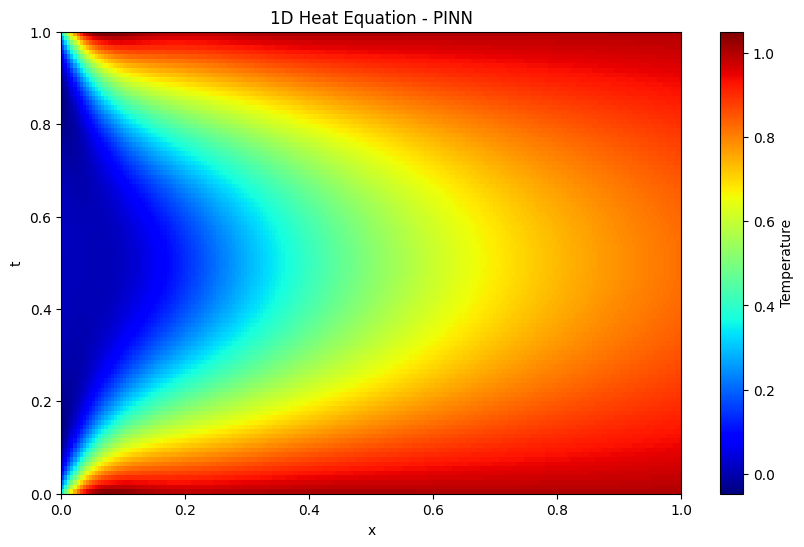

In [12]:
plt.figure(figsize=(10,6))

plt.imshow(
    U,
    extent=[0,1,0,1],
    origin='lower',
    aspect='auto',
    cmap='jet'
)

plt.colorbar(label='Temperature')

plt.xlabel('x')

plt.ylabel('t')

plt.title('1D Heat Equation - PINN')

plt.savefig('2D.png')

plt.show()

# 3D

In [13]:
from mpl_toolkits.mplot3d import Axes3D

In [14]:
nx = 100
nt = 100

x = torch.linspace(0,1,nx)

t = torch.linspace(0,1,nt)

T, X = torch.meshgrid(
    t,
    x,
    indexing='ij'
)

In [15]:
x_test = X.reshape(-1,1)

t_test = T.reshape(-1,1)

In [16]:
with torch.no_grad():

    U = model(
        t_test,
        x_test
    )

In [17]:
U = U.reshape(nt,nx)

U = U.numpy()

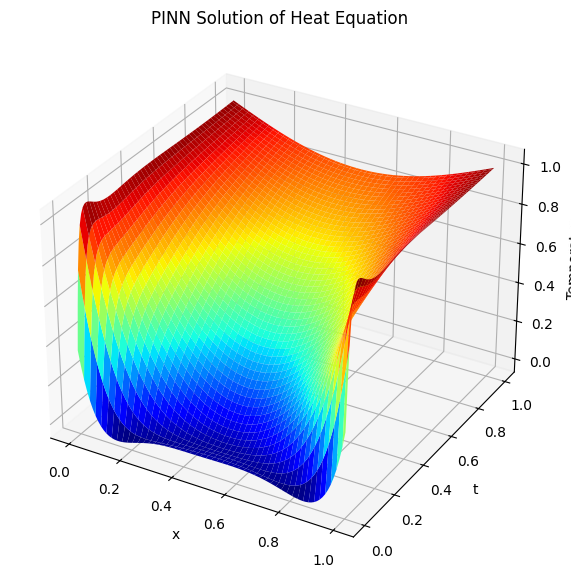

In [18]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.set_xlabel('x')

ax.set_ylabel('t')

ax.set_zlabel('Temperature')

ax.set_title('PINN Solution of Heat Equation')

surf = ax.plot_surface(
    X.numpy(),
    T.numpy(),
    U,
    cmap='jet'
)

plt.savefig('3D.png')